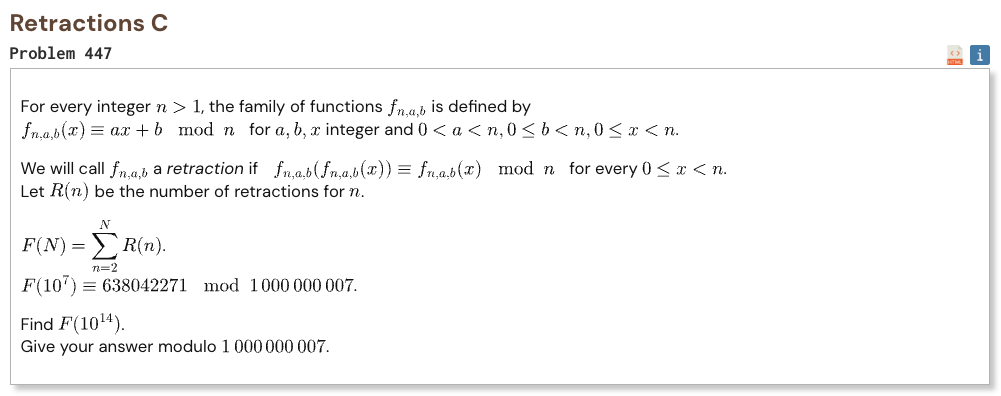

## Initial approach

-   rewrite the number of retractions using the sum of unitary divisors
-   turn the whole problem into finding a cumulative unitary divisor sum up to a very large limit
-   use Möbius inversion to replace the coprime condition with a much easier weighted sum
-   only Möbius values up to the square root of the limit are needed
-   generate those Möbius values efficiently with a linear sieve
-   group consecutive divisors that give the same integer quotient instead of checking them one by one
-   this reduces each inner divisor sum to about square root time
-   combine all contributions and subtract the ordinary integer sum at the end

In [1]:
from math import isqrt

MOD = 1_000_000_007

def solve(N):
    limit = isqrt(N)

    mu = [0] * (limit + 1)
    mu[1] = 1

    primes = []
    composite = bytearray(limit + 1)

    for i in range(2, limit + 1):
        if not composite[i]:
            primes.append(i)
            mu[i] = -1

        for p in primes:
            v = i * p

            if v > limit:
                break

            composite[v] = 1

            if i % p == 0:
                mu[v] = 0
                break

            mu[v] = -mu[i]

    def divisor_sum_prefix(M):
        total = 0
        k = 1

        while k <= M:
            q = M // k
            last = M // q

            count = last - k + 1
            interval_sum = (k + last) * count // 2

            total += q * interval_sum
            total %= MOD

            k = last + 1

        return total

    unitary_sum = 0

    for e in range(1, limit + 1):
        if mu[e] == 0:
            continue

        M = N // (e * e)

        unitary_sum += mu[e] * e * divisor_sum_prefix(M)
        unitary_sum %= MOD

    integer_sum = N % MOD
    integer_sum *= (N + 1) % MOD
    integer_sum %= MOD
    integer_sum *= pow(2, MOD - 2, MOD)
    integer_sum %= MOD

    result = (unitary_sum - integer_sum) % MOD

    return result

In [2]:
%%time

N = 10**14
result = solve(N)

print("Result:", result)

Result: 530553372
CPU times: user 30.5 s, sys: 147 ms, total: 30.6 s
Wall time: 31.1 s
